# Transformer Fine-Tuning & Cross-Category Evaluation

In [1]:
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn accelerate -q

In [6]:
CATEGORIES = [
    "Electronics",
    "Books",
    "Clothing_Shoes_and_Jewelry",
    "Home_and_Kitchen",
    "Toys_and_Games",
]

CATEGORY_LABELS = [
    "Electronics", "Books", "Clothing", "Home & Kitchen", "Toys"
]

FILE_STEMS = {
    "Electronics":                "electronics",
    "Books":                      "books",
    "Clothing_Shoes_and_Jewelry": "clothing",
    "Home_and_Kitchen":           "home_kitchen",
    "Toys_and_Games":             "toys",
}

MODEL_NAME      = "roberta-base"
DISTILBERT_NAME = "distilbert-base-uncased"
BERT_NAME       = "bert-base-uncased"
MAX_LENGTH          = 128
TRAIN_EPOCHS        = 3
TRAIN_BATCH_SIZE    = 16
EVAL_BATCH_SIZE     = 32
LEARNING_RATE       = 2e-5
WEIGHT_DECAY        = 0.01
EARLY_STOP_PATIENCE = 1
RANDOM_SEED         = 104
DRIVE_BASE          = "/content/drive/MyDrive/cross-category-sentiment-robustness"

In [4]:
import os, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    RobertaTokenizerFast, RobertaForSequenceClassification,
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    BertTokenizerFast, BertForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
)
from google.colab import drive

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

drive.mount("/content/drive")
DATA_DIR    = f"{DRIVE_BASE}/data"
MODELS_DIR  = f"{DRIVE_BASE}/models"
RESULTS_DIR = f"{DRIVE_BASE}/results"
FIGURES_DIR = f"{DRIVE_BASE}/figures"

for d in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

Device: cuda
Mounted at /content/drive


In [5]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt"
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

def load_split(stem: str, split: str) -> pd.DataFrame:
    df = pd.read_csv(f"{DATA_DIR}/{stem}_{split}.csv")
    df["text"] = df["text"].fillna("").astype(str)
    return df

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds, average="macro"),
    }

def build_matrix(results: dict, metric: str) -> pd.DataFrame:
    mat = pd.DataFrame(index=CATEGORIES, columns=CATEGORIES, dtype=float)
    for src in CATEGORIES:
        for tgt in CATEGORIES:
            mat.loc[src, tgt] = results[src][tgt][metric]
    mat.index   = CATEGORY_LABELS
    mat.columns = CATEGORY_LABELS
    return mat

def plot_heatmap(mat: pd.DataFrame, title: str, filename: str):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        mat.astype(float), annot=True, fmt=".3f",
        cmap="Blues", vmin=0.5, vmax=1.0,
        linewidths=0.5, ax=ax,
    )
    ax.set_xlabel("Target category", fontsize=11)
    ax.set_ylabel("Source category", fontsize=11)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{filename}", dpi=150)
    plt.show()

## 1  RoBERTa-base

In [7]:
tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [32]:
# Per-model LR sweep on Electronics proxy set

PROXY_N = 1000

_proxy_full = load_split(FILE_STEMS["Electronics"], "train")
_proxy_train = (
    _proxy_full
    .groupby("label", group_keys=False)
    .apply(lambda g: g.sample(PROXY_N // 2, random_state=RANDOM_SEED))
    .reset_index(drop=True)
)
_proxy_val = load_split(FILE_STEMS["Electronics"], "val")
print(f"Proxy train: {len(_proxy_train)} | Proxy val: {len(_proxy_val)}")

def _lr_sweep(model_class, model_name, tok, lr_candidates, fp16_flag: bool) -> float:
    """2-epoch proxy runs per LR; returns LR with best val macro-F1."""
    val_ds = ReviewDataset(_proxy_val["text"], _proxy_val["label"], tok, MAX_LENGTH)
    best = []
    print(f"{'LR':>8}  {'Val Acc':>9}  {'Val F1':>8}")
    for _lr in lr_candidates:
        _ds  = ReviewDataset(_proxy_train["text"], _proxy_train["label"], tok, MAX_LENGTH)
        _mdl = model_class.from_pretrained(model_name, num_labels=2)
        _args = TrainingArguments(
            output_dir="/tmp/lr_sweep",
            num_train_epochs=2,
            per_device_train_batch_size=TRAIN_BATCH_SIZE,
            per_device_eval_batch_size=EVAL_BATCH_SIZE,
            learning_rate=_lr,
            weight_decay=WEIGHT_DECAY,
            eval_strategy="no",
            save_strategy="no",
            fp16=fp16_flag,
            warmup_ratio=0.06,
            seed=RANDOM_SEED,
            logging_steps=999999,
            report_to="none",
        )
        _trainer = Trainer(model=_mdl, args=_args, train_dataset=_ds, processing_class=tok)
        _trainer.train()
        _out  = _trainer.predict(val_ds)
        _pred = _out.predictions.argmax(-1)
        _true = val_ds.labels.numpy()
        _acc  = accuracy_score(_true, _pred)
        _f1   = f1_score(_true, _pred, average="macro")
        print(f"{_lr:>8.0e}  {_acc:>9.4f}  {_f1:>8.4f}")
        best.append((_lr, _f1))
        del _mdl
    chosen = max(best, key=lambda x: x[1])[0]
    print(f"  [*] best LR = {chosen:.0e}")
    return chosen

# RoBERTa: fp16=False required for stability; lower LR range
print()
print("RoBERTa LR sweep")
ROBERTA_LR = _lr_sweep(
    RobertaForSequenceClassification, MODEL_NAME, tokenizer,
    lr_candidates=[5e-6, 1e-5, 2e-5, 3e-5],
    fp16_flag=False,
)
print(f"RoBERTa LR = {ROBERTA_LR:.0e}")

/tmp/ipykernel_1060/1481070953.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(PROXY_N // 2, random_state=RANDOM_SEED))


Proxy train: 1000 | Proxy val: 750

RoBERTa LR sweep
      LR    Val Acc    Val F1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss


...

   2e-05     0.5387    0.4549


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss


   3e-05     0.5413    0.4900
  [*] best LR = 3e-05
RoBERTa LR = 3e-05


In [9]:
def fine_tune(source_cat: str) -> str:
    stem      = FILE_STEMS[source_cat]
    model_dir = f"{MODELS_DIR}/roberta_{stem}"

    df_train = load_split(stem, "train")
    df_val   = load_split(stem, "val")

    train_ds = ReviewDataset(df_train["text"], df_train["label"], tokenizer, MAX_LENGTH)
    val_ds   = ReviewDataset(df_val["text"],   df_val["label"],   tokenizer, MAX_LENGTH)

    model = RobertaForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    args = TrainingArguments(
        output_dir=model_dir,
        num_train_epochs=TRAIN_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=ROBERTA_LR,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        fp16=False,
        warmup_ratio=0.06,
        seed=RANDOM_SEED,
        logging_steps=50,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        processing_class=tokenizer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
    )

    print()
    print(f"Fine-tuning RoBERTa on {source_cat} (lr={ROBERTA_LR:.0e}) ...")
    print(f"  train={len(df_train)}, val={len(df_val)}")
    trainer.train()
    trainer.save_model(model_dir)
    tokenizer.save_pretrained(model_dir)
    print(f"  Saved {model_dir}")
    return model_dir

In [10]:
def evaluate_on(model_dir: str, target_cat: str) -> dict:
    """Load saved model and evaluate on target_cat test set."""
    stem    = FILE_STEMS[target_cat]
    df_test = load_split(stem, "test")
    test_ds = ReviewDataset(df_test["text"], df_test["label"], tokenizer, MAX_LENGTH)

    model = RobertaForSequenceClassification.from_pretrained(model_dir)
    eval_args = TrainingArguments(
        output_dir="/tmp/eval",
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        fp16=torch.cuda.is_available(),
        report_to="none",
    )
    trainer = Trainer(
        model=model,
        args=eval_args,
        compute_metrics=compute_metrics,
        processing_class=tokenizer,
    )
    out    = trainer.predict(test_ds)
    preds  = np.argmax(out.predictions, axis=-1)
    y_true = df_test["label"].values
    return {
        "accuracy": accuracy_score(y_true, preds),
        "f1":       f1_score(y_true, preds, average="macro"),
        "y_true":   y_true,
        "y_pred":   preds,
    }

In [33]:
roberta_results: dict[str, dict] = {}

for source_cat in CATEGORIES:
    model_dir = fine_tune(source_cat)
    roberta_results[source_cat] = {}

    for target_cat in CATEGORIES:
        res = evaluate_on(model_dir, target_cat)
        roberta_results[source_cat][target_cat] = res
        tag = "(in-domain)" if source_cat == target_cat else ""
        print(f"  {target_cat:<35} acc={res['accuracy']:.3f}  f1={res['f1']:.3f} {tag}")

print()
print("All RoBERTa training & evaluation complete.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Fine-tuning RoBERTa on Electronics (lr=3e-05) ...
  train=3500, val=750


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.697460,0.693460,0.500000,0.333333
2,0.696107,0.693444,0.500000,0.333333
3,0.694707,0.693338,0.500000,0.333333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  Clothing_Shoes_and_Jewelry          acc=0.661  f1=0.654 


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Home_and_Kitchen                    acc=0.613  f1=0.594 


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Toys_and_Games                      acc=0.751  f1=0.749 (in-domain)

All RoBERTa training & evaluation complete.


In [34]:
# RoBERTa: hardcoded, proxy sweep is unreliable with fp16=False
ROBERTA_LR = 1e-5
print(f"RoBERTa LR = {ROBERTA_LR:.0e}  (hardcoded; proxy sweep unreliable for RoBERTa)")

RoBERTa LR = 1e-05  (hardcoded; proxy sweep unreliable for RoBERTa)


In [13]:
roberta_results: dict[str, dict] = {}

for source_cat in CATEGORIES:
    model_dir = fine_tune(source_cat)
    roberta_results[source_cat] = {}

    for target_cat in CATEGORIES:
        res = evaluate_on(model_dir, target_cat)
        roberta_results[source_cat][target_cat] = res
        tag = "(in-domain)" if source_cat == target_cat else ""
        print(f"  {target_cat:<35} acc={res['accuracy']:.3f}  f1={res['f1']:.3f} {tag}")

print()
print("All RoBERTa training & evaluation complete.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Fine-tuning RoBERTa on Electronics (lr=1e-05) ...
  train=3500, val=750


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.683783,0.656740,0.586667,0.529215
2,0.564947,0.546260,0.709333,0.709201
3,0.542604,0.543651,0.710667,0.710662


...

  Clothing_Shoes_and_Jewelry          acc=0.660  f1=0.652 


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Home_and_Kitchen                    acc=0.628  f1=0.610 


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Toys_and_Games                      acc=0.761  f1=0.760 (in-domain)

All RoBERTa training & evaluation complete.


In [14]:
rob_acc = build_matrix(roberta_results, "accuracy")
rob_f1  = build_matrix(roberta_results, "f1")

rob_acc.to_csv(f"{RESULTS_DIR}/roberta_transfer_matrix.csv")
rob_f1.to_csv(f"{RESULTS_DIR}/roberta_transfer_matrix_f1.csv")

print("Saved RoBERTa transfer matrices.")
print()
print("RoBERTa accuracy matrix:")
print(rob_acc.to_string())

Saved RoBERTa transfer matrices.

RoBERTa accuracy matrix:
                Electronics     Books  Clothing  Home & Kitchen      Toys
Electronics        0.716000  0.653333  0.682667        0.678667  0.690667
Books              0.684000  0.708000  0.644000        0.632000  0.696000
Clothing           0.661333  0.630667  0.718667        0.690667  0.725333
Home & Kitchen     0.638667  0.580000  0.676000        0.706667  0.640000
Toys               0.649333  0.652000  0.660000        0.628000  0.761333


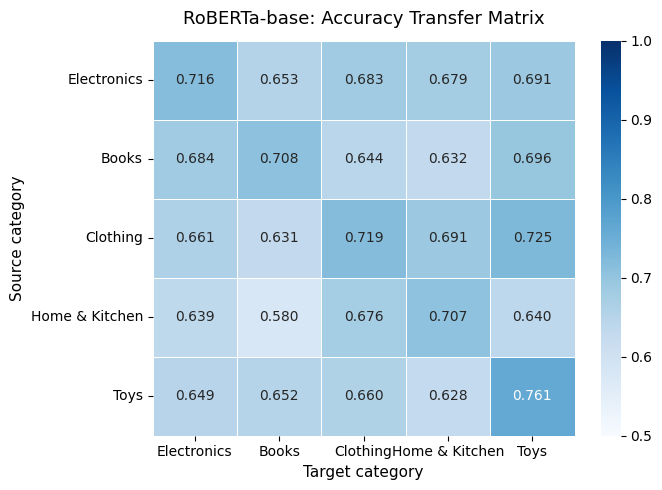

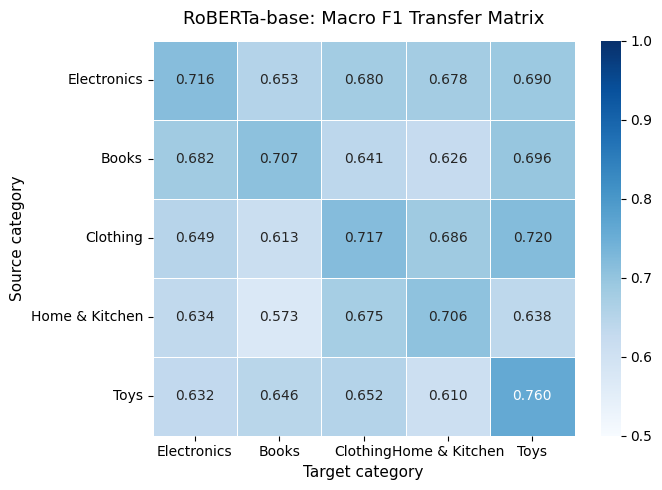

In [15]:
plot_heatmap(rob_acc, "RoBERTa-base: Accuracy Transfer Matrix", "heatmap_roberta.png")
plot_heatmap(rob_f1,  "RoBERTa-base: Macro F1 Transfer Matrix", "heatmap_roberta_f1.png")

## 2  DistilBERT-base-uncased

In [16]:
distilbert_tokenizer = DistilBertTokenizerFast.from_pretrained(DISTILBERT_NAME)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [17]:
# DistilBERT: fp16 safe; standard LR range
print("DistilBERT LR sweep")
DISTILBERT_LR = _lr_sweep(
    DistilBertForSequenceClassification, DISTILBERT_NAME, distilbert_tokenizer,
    lr_candidates=[1e-5, 2e-5, 3e-5, 5e-5],
    fp16_flag=torch.cuda.is_available(),
)
print(f"[*] DistilBERT LR = {DISTILBERT_LR:.0e}")

DistilBERT LR sweep
      LR    Val Acc    Val F1


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

   3e-05     0.9067    0.9067


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss


   5e-05     0.8987    0.8985
  [*] best LR = 3e-05
[*] DistilBERT LR = 3e-05


In [18]:
def fine_tune_distilbert(source_cat: str) -> str:
    stem      = FILE_STEMS[source_cat]
    model_dir = f"{MODELS_DIR}/distilbert_{stem}"

    df_train = load_split(stem, "train")
    df_val   = load_split(stem, "val")

    train_ds = ReviewDataset(df_train["text"], df_train["label"], distilbert_tokenizer, MAX_LENGTH)
    val_ds   = ReviewDataset(df_val["text"],   df_val["label"],   distilbert_tokenizer, MAX_LENGTH)

    model = DistilBertForSequenceClassification.from_pretrained(DISTILBERT_NAME, num_labels=2)
    fp16  = torch.cuda.is_available()

    args = TrainingArguments(
        output_dir=model_dir,
        num_train_epochs=TRAIN_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=DISTILBERT_LR,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        fp16=fp16,
        warmup_ratio=0.06,
        seed=RANDOM_SEED,
        logging_steps=50,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        processing_class=distilbert_tokenizer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
    )

    print()
    print(f"Fine-tuning DistilBERT on {source_cat} (lr={DISTILBERT_LR:.0e}) ...")
    print(f"  train={len(df_train)}, val={len(df_val)}")
    trainer.train()
    trainer.save_model(model_dir)
    distilbert_tokenizer.save_pretrained(model_dir)
    print(f"  Saved {model_dir}")
    return model_dir

In [19]:
def evaluate_on_distilbert(model_dir: str, target_cat: str) -> dict:
    stem    = FILE_STEMS[target_cat]
    df_test = load_split(stem, "test")
    test_ds = ReviewDataset(df_test["text"], df_test["label"], distilbert_tokenizer, MAX_LENGTH)

    model = DistilBertForSequenceClassification.from_pretrained(model_dir)
    eval_args = TrainingArguments(
        output_dir="/tmp/eval_distilbert",
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        fp16=torch.cuda.is_available(),
        report_to="none",
    )
    trainer = Trainer(
        model=model,
        args=eval_args,
        compute_metrics=compute_metrics,
        processing_class=distilbert_tokenizer,
    )
    out    = trainer.predict(test_ds)
    preds  = np.argmax(out.predictions, axis=-1)
    y_true = df_test["label"].values
    return {
        "accuracy": accuracy_score(y_true, preds),
        "f1":       f1_score(y_true, preds, average="macro"),
        "y_true":   y_true,
        "y_pred":   preds,
    }

In [20]:
distilbert_results: dict[str, dict] = {}

for source_cat in CATEGORIES:
    model_dir = fine_tune_distilbert(source_cat)
    distilbert_results[source_cat] = {}

    for target_cat in CATEGORIES:
        res = evaluate_on_distilbert(model_dir, target_cat)
        distilbert_results[source_cat][target_cat] = res
        tag = "(in-domain)" if source_cat == target_cat else ""
        print(f"  {target_cat:<35} acc={res['accuracy']:.3f}  f1={res['f1']:.3f} {tag}")

print()
print("All DistilBERT training & evaluation complete.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Fine-tuning DistilBERT on Electronics (lr=3e-05) ...
  train=3500, val=750


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.264322,0.190133,0.917333,0.917331
2,0.131953,0.220049,0.920000,0.919943


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  Clothing_Shoes_and_Jewelry          acc=0.881  f1=0.881 


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  Home_and_Kitchen                    acc=0.875  f1=0.874 


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  Toys_and_Games                      acc=0.933  f1=0.933 (in-domain)

All DistilBERT training & evaluation complete.


In [21]:
distil_acc = build_matrix(distilbert_results, "accuracy")
distil_f1  = build_matrix(distilbert_results, "f1")

distil_acc.to_csv(f"{RESULTS_DIR}/distilbert_transfer_matrix.csv")
distil_f1.to_csv(f"{RESULTS_DIR}/distilbert_transfer_matrix_f1.csv")

print("Saved DistilBERT transfer matrices.")
print()
print("DistilBERT accuracy matrix:")
print(distil_acc.to_string())

Saved DistilBERT transfer matrices.

DistilBERT accuracy matrix:
                Electronics     Books  Clothing  Home & Kitchen      Toys
Electronics        0.936000  0.877333  0.894667        0.906667  0.925333
Books              0.870667  0.918667  0.844000        0.833333  0.909333
Clothing           0.918667  0.856000  0.910667        0.910667  0.918667
Home & Kitchen     0.914667  0.865333  0.898667        0.912000  0.934667
Toys               0.898667  0.866667  0.881333        0.874667  0.933333


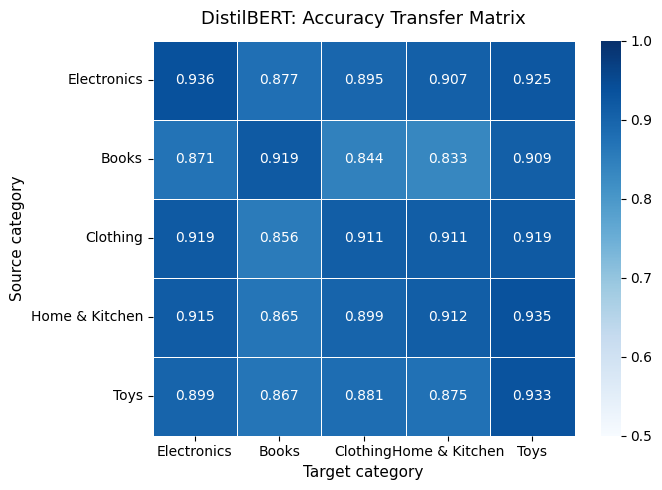

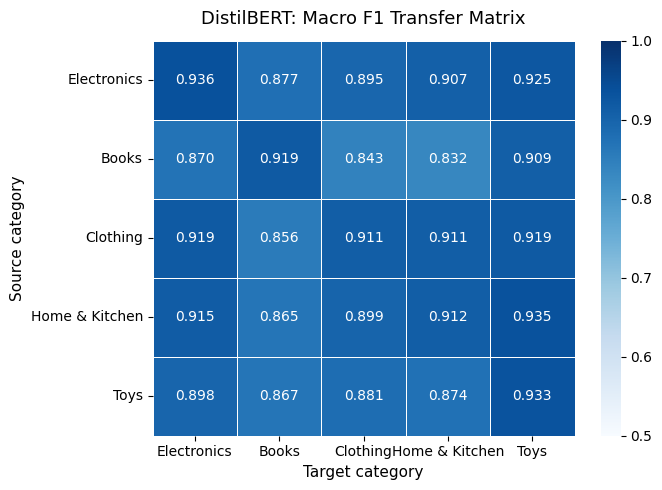

In [22]:
plot_heatmap(distil_acc, "DistilBERT: Accuracy Transfer Matrix", "heatmap_distilbert.png")
plot_heatmap(distil_f1,  "DistilBERT: Macro F1 Transfer Matrix", "heatmap_distilbert_f1.png")

## 3  BERT-base-uncased

In [23]:
bert_tokenizer = BertTokenizerFast.from_pretrained(BERT_NAME)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [24]:
# BERT: fp16 safe; standard LR range
print("BERT LR sweep")
BERT_LR = _lr_sweep(
    BertForSequenceClassification, BERT_NAME, bert_tokenizer,
    lr_candidates=[1e-5, 2e-5, 3e-5, 5e-5],
    fp16_flag=torch.cuda.is_available(),
)
print(f"[*] BERT LR = {BERT_LR:.0e}")

BERT LR sweep
      LR    Val Acc    Val F1


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

...

   3e-05     0.9160    0.9160


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

Step,Training Loss


   5e-05     0.9200    0.9199
  [*] best LR = 5e-05
[*] BERT LR = 5e-05


In [25]:
def fine_tune_bert(source_cat: str) -> str:
    stem      = FILE_STEMS[source_cat]
    model_dir = f"{MODELS_DIR}/bert_{stem}"

    df_train = load_split(stem, "train")
    df_val   = load_split(stem, "val")

    train_ds = ReviewDataset(df_train["text"], df_train["label"], bert_tokenizer, MAX_LENGTH)
    val_ds   = ReviewDataset(df_val["text"],   df_val["label"],   bert_tokenizer, MAX_LENGTH)

    model = BertForSequenceClassification.from_pretrained(BERT_NAME, num_labels=2)

    args = TrainingArguments(
        output_dir=model_dir,
        num_train_epochs=TRAIN_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=BERT_LR,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        fp16=torch.cuda.is_available(),
        warmup_ratio=0.06,
        seed=RANDOM_SEED,
        logging_steps=50,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        processing_class=bert_tokenizer,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
    )

    print()
    print(f"Fine-tuning BERT on {source_cat} (lr={BERT_LR:.0e}) ...")
    print(f"  train={len(df_train)}, val={len(df_val)}")
    trainer.train()
    trainer.save_model(model_dir)
    bert_tokenizer.save_pretrained(model_dir)
    print(f"  Saved {model_dir}")
    return model_dir

In [26]:
def evaluate_on_bert(model_dir: str, target_cat: str) -> dict:
    stem    = FILE_STEMS[target_cat]
    df_test = load_split(stem, "test")
    test_ds = ReviewDataset(df_test["text"], df_test["label"], bert_tokenizer, MAX_LENGTH)

    model = BertForSequenceClassification.from_pretrained(model_dir)
    eval_args = TrainingArguments(
        output_dir="/tmp/eval_bert",
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        fp16=torch.cuda.is_available(),
        report_to="none",
    )
    trainer = Trainer(
        model=model,
        args=eval_args,
        compute_metrics=compute_metrics,
        processing_class=bert_tokenizer,
    )
    out    = trainer.predict(test_ds)
    preds  = np.argmax(out.predictions, axis=-1)
    y_true = df_test["label"].values
    return {
        "accuracy": accuracy_score(y_true, preds),
        "f1":       f1_score(y_true, preds, average="macro"),
        "y_true":   y_true,
        "y_pred":   preds,
    }

In [27]:
bert_results: dict[str, dict] = {}

for source_cat in CATEGORIES:
    model_dir = fine_tune_bert(source_cat)
    bert_results[source_cat] = {}

    for target_cat in CATEGORIES:
        res = evaluate_on_bert(model_dir, target_cat)
        bert_results[source_cat][target_cat] = res
        tag = "(in-domain)" if source_cat == target_cat else ""
        print(f"  {target_cat:<35} acc={res['accuracy']:.3f}  f1={res['f1']:.3f} {tag}")

print()
print("All BERT training & evaluation complete.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b


Fine-tuning BERT on Electronics (lr=5e-05) ...
  train=3500, val=750


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.264812,0.167737,0.936000,0.935971
2,0.126695,0.168508,0.946667,0.946665


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  Clothing_Shoes_and_Jewelry          acc=0.913  f1=0.913 


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Home_and_Kitchen                    acc=0.900  f1=0.900 


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Toys_and_Games                      acc=0.948  f1=0.948 (in-domain)

All BERT training & evaluation complete.


In [28]:
bert_acc = build_matrix(bert_results, "accuracy")
bert_f1  = build_matrix(bert_results, "f1")

bert_acc.to_csv(f"{RESULTS_DIR}/bert_transfer_matrix.csv")
bert_f1.to_csv(f"{RESULTS_DIR}/bert_transfer_matrix_f1.csv")

print("Saved BERT transfer matrices.")
print()
print("BERT accuracy matrix:")
print(bert_acc.to_string())

Saved BERT transfer matrices.

BERT accuracy matrix:
                Electronics     Books  Clothing  Home & Kitchen      Toys
Electronics        0.941333  0.876000  0.889333        0.917333  0.945333
Books              0.896000  0.928000  0.897333        0.866667  0.924000
Clothing           0.917333  0.848000  0.917333        0.906667  0.929333
Home & Kitchen     0.904000  0.842667  0.912000        0.917333  0.901333
Toys               0.908000  0.885333  0.913333        0.900000  0.948000


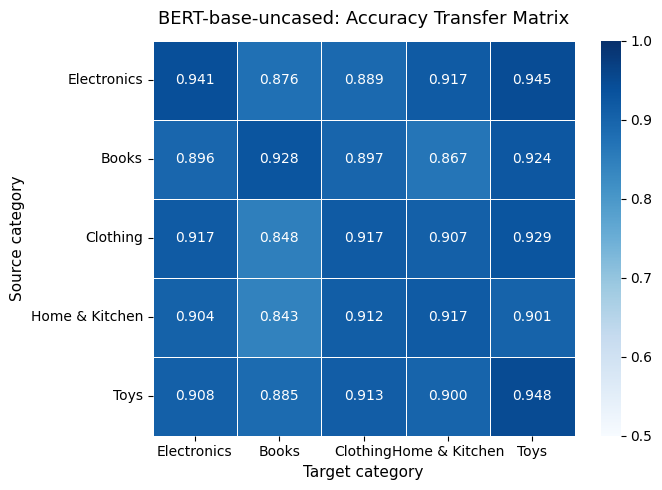

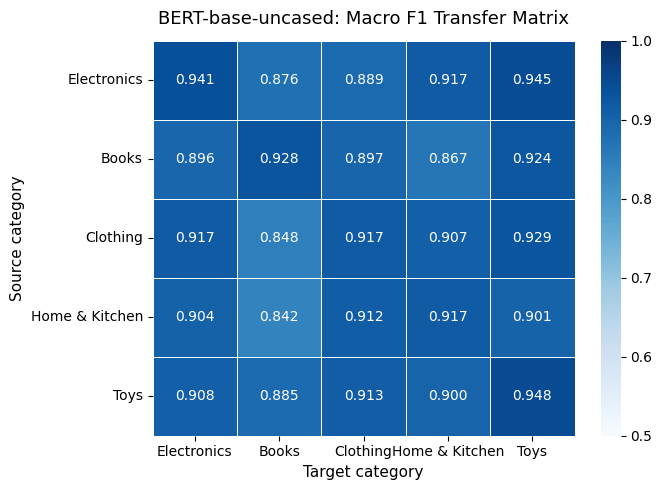

In [29]:
plot_heatmap(bert_acc, "BERT-base-uncased: Accuracy Transfer Matrix", "heatmap_bert.png")
plot_heatmap(bert_f1,  "BERT-base-uncased: Macro F1 Transfer Matrix", "heatmap_bert_f1.png")

## 4  Seven-model comparison

Seven-model comparison:
     Model  In-domain mean  Cross-domain mean  Degradation
    LogReg           0.911              0.848        0.063
       SVM           0.901              0.833        0.068
        NB           0.900              0.833        0.067
        RF           0.876              0.788        0.088
   RoBERTa           0.722              0.660        0.062
DistilBERT           0.922              0.890        0.032
      BERT           0.930              0.899        0.031


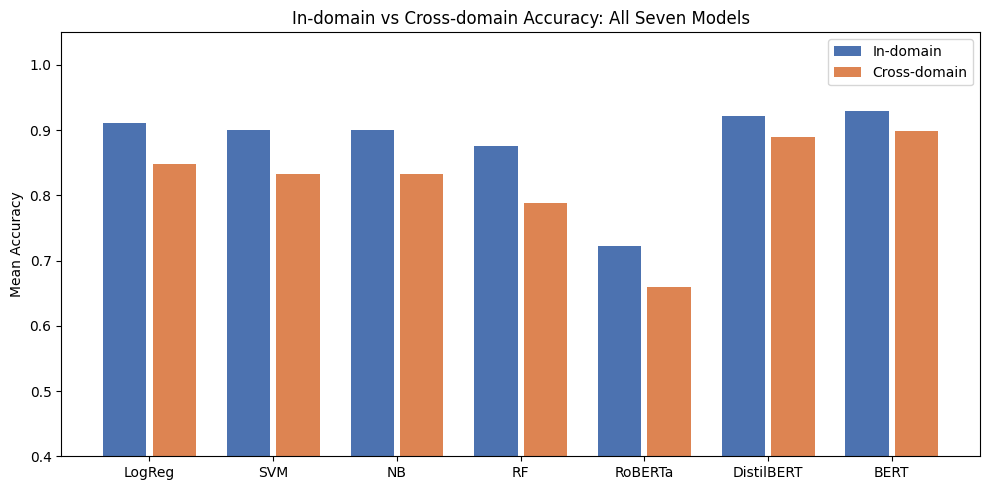

In [30]:
logreg_acc = pd.read_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_logreg.csv", index_col=0)
svm_acc    = pd.read_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_svm.csv",    index_col=0)
nb_acc     = pd.read_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_nb.csv",     index_col=0)
rf_acc     = pd.read_csv(f"{RESULTS_DIR}/baseline_transfer_matrix_rf.csv",     index_col=0)

all_models = {
    "LogReg": logreg_acc, "SVM": svm_acc, "NB": nb_acc, "RF": rf_acc,
    "RoBERTa": rob_acc, "DistilBERT": distil_acc, "BERT": bert_acc,
}

rows = []
for name, mat in all_models.items():
    m    = mat.values.astype(float)
    n    = m.shape[0]
    diag = np.diag(m)
    off  = m[~np.eye(n, dtype=bool)]
    rows.append({
        "Model":             name,
        "In-domain mean":    round(diag.mean(), 3),
        "Cross-domain mean": round(off.mean(),  3),
        "Degradation":       round(diag.mean() - off.mean(), 3),
    })

summary = pd.DataFrame(rows)
print("Seven-model comparison:")
print(summary.to_string(index=False))

x = np.arange(len(all_models))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, summary["In-domain mean"],    0.35, label="In-domain",    color="#4c72b0")
ax.bar(x + 0.2, summary["Cross-domain mean"], 0.35, label="Cross-domain", color="#dd8452")
ax.set_xticks(x)
ax.set_xticklabels(summary["Model"])
ax.set_ylim(0.4, 1.05)
ax.set_ylabel("Mean Accuracy")
ax.set_title("In-domain vs Cross-domain Accuracy: All Seven Models")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/accuracy_comparison_all_models.png", dpi=150)
plt.show()